# atividade 1:

1. Admitindo a abordagem baseada em SSE para o treinamento da fase supervisionada da RBFNet, sabe-se que a existência de padrões idênticos na base de treinamento pode tornar singular, ou numericamente mal condicionada, a matriz envolvida no cálculo dos pesos que conectam as camadas intermediária e de saída. Diante dessa questão, proponha uma estratégia para lidar com esse problema. Implemente sua proposta e aplique-a no conjunto de dados gerado artificialmente pelo código abaixo:
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X = np.vstack([X, X[:20]]) #Vamos forçar a repetição aqui...
y = np.hstack([y, y[:20]])

1. O Problema da Singularidade na RBFNetPor que padrões idênticos causam problemas?Na fase supervisionada de uma rede RBF (Radial Basis Function), nós comumente calculamos os pesos da camada de saída resolvendo um problema de Mínimos Quadrados (Sum of Squared Errors - SSE). Se $H$ é a matriz de ativação da camada oculta (onde cada elemento $H_{ij}$ é a saída do neurônio RBF $j$ para a amostra $i$) e $y$ é o vetor de rótulos esperados, os pesos $W$ são encontrados pela equação normal:$$W = (H^T H)^{-1} H^T y$$Quando temos padrões idênticos na base de treinamento (ou seja, vetores $x_i = x_k$), as distâncias desses pontos para os centros da RBF serão exatamente as mesmas. Isso resulta em linhas idênticas na matriz de ativação $H$.Matematicamente, quando uma matriz possui linhas ou colunas linearmente dependentes (neste caso, idênticas), o determinante da matriz resultante $H^T H$ torna-se zero (ou muito próximo de zero, devido a imprecisões de ponto flutuante). Dizemos que a matriz é singular ou numericamente mal condicionada. Consequentemente, a operação de inversão $(H^T H)^{-1}$ torna-se instável ou impossível, levando a pesos que "explodem" (valores infinitos ou gigantescos), destruindo a capacidade de generalização da rede.

2. Estratégias para Lidar com o ProblemaPara resolver este problema de álgebra linear, proponho duas estratégias excelentes que você pode adotar (e até discutir no seu relatório em LaTeX):Estratégia A: Pré-processamento (Remoção de Duplicatas)A abordagem mais direta e higiênica. Antes de passar os dados para a rede, nós filtramos as amostras idênticas. Se dois padrões trazem exatamente a mesma informação posicional, remover as duplicatas evita a dependência linear sem perda de diversidade para a fase não-supervisionada (K-Means, por exemplo).Estratégia B: Regularização de Tikhonov (Ridge Regression)Esta é a solução matemática mais robusta. Nós adicionamos um termo de penalidade $\lambda$ à diagonal principal da matriz antes de invertê-la. A equação se torna:$$W = (H^T H + \lambda I)^{-1} H^T y$$Onde $I$ é a matriz identidade. A soma de $\lambda I$ garante que os autovalores da matriz sejam estritamente positivos, tornando-a sempre invertível, mesmo com repetições. Essa técnica também ajuda a prevenir overfitting.

3. Implementação Prática
Vamos implementar ambas as estratégias usando a base fornecida no enunciado. Você pode integrar esta lógica no seu código da RBFNet.

In [3]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge

# ==========================================
# Geração dos Dados (Conforme o enunciado)
# ==========================================
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X = np.vstack([X, X[:20]]) # Forçando a repetição
y = np.hstack([y, y[:20]])

print(f"Dimensão original de X com repetições: {X.shape}")

# ==========================================
# Estratégia A: Remoção de Duplicatas
# ==========================================
# Utilizamos o return_index=True para pegar os índices únicos 
# e garantir que os rótulos (y) correspondam corretamente.
X_unique, indices_unicos = np.unique(X, axis=0, return_index=True)
y_unique = y[indices_unicos]

print(f"Dimensão de X após remoção de duplicatas: {X_unique.shape}")

# ==========================================
# Estratégia B: Regularização (Ridge) na RBFNet
# ==========================================
# Vamos simular a fase não supervisionada (centros) e a matriz H
num_centros = 50
kmeans = KMeans(n_clusters=num_centros, random_state=42, n_init=10)
kmeans.fit(X) # Note que passamos o X com repetição aqui para demonstrar a robustez
centros = kmeans.cluster_centers_

# Calculando a matriz de ativação (H) usando Kernel RBF (gamma=15 como exemplo)
gamma_val = 15.0
H = rbf_kernel(X, centros, gamma=gamma_val)

# Ao invés de usar np.linalg.pinv(H), usamos o Ridge do scikit-learn
# O parâmetro 'alpha' é o nosso lambda (termo de regularização de Tikhonov)
lambda_reg = 1e-4 
classificador_saida = Ridge(alpha=lambda_reg)

# O treinamento agora é seguro contra a matriz mal condicionada
classificador_saida.fit(H, y)
y_pred = classificador_saida.predict(H)

# Binarizando a saída (já que as classes originais são 0 e 1)
y_pred_class = np.where(y_pred >= 0.5, 1, 0)
acuracia = np.mean(y_pred_class == y)

print(f"Acurácia no treinamento com Regularização (Ridge): {acuracia*100:.2f}%")

Dimensão original de X com repetições: (520, 2)
Dimensão de X após remoção de duplicatas: (500, 2)
Acurácia no treinamento com Regularização (Ridge): 100.00%


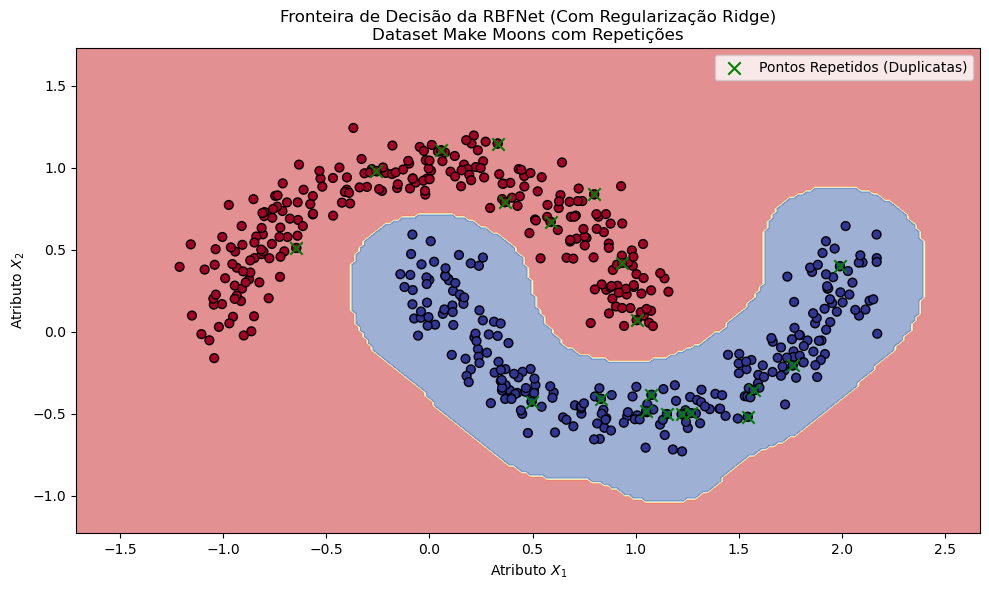

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge

# ==========================================
# 1. Geração dos Dados
# ==========================================
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X = np.vstack([X, X[:20]]) # Forçando a repetição
y = np.hstack([y, y[:20]])

# ==========================================
# 2. Fase Não-Supervisionada e Treinamento (RBFNet + Ridge)
# ==========================================
num_centros = 50
kmeans = KMeans(n_clusters=num_centros, random_state=42, n_init=10)
kmeans.fit(X)
centros = kmeans.cluster_centers_

gamma_val = 15.0
H = rbf_kernel(X, centros, gamma=gamma_val)

lambda_reg = 1e-4 
classificador_saida = Ridge(alpha=lambda_reg)
classificador_saida.fit(H, y)

# ==========================================
# 3. Visualização da Fronteira de Decisão
# ==========================================
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

pontos_malha = np.c_[xx.ravel(), yy.ravel()]
H_malha = rbf_kernel(pontos_malha, centros, gamma=gamma_val)
Z = classificador_saida.predict(H_malha)
Z_class = np.where(Z >= 0.5, 1, 0)
Z_class = Z_class.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_class, alpha=0.5, cmap=plt.cm.RdYlBu)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu, s=40)
plt.scatter(X[-20:, 0], X[-20:, 1], color='green', marker='x', s=80, 
            label='Pontos Repetidos (Duplicatas)')

plt.title('Fronteira de Decisão da RBFNet (Com Regularização Ridge)\nDataset Make Moons com Repetições')
plt.xlabel('Atributo $X_1$')
plt.ylabel('Atributo $X_2$')
plt.legend()
plt.tight_layout()

# Salva a imagem no seu diretório para usar no relatório LaTeX
plt.savefig('fronteira_rbf.png', dpi=300) 
plt.show()

O que você observará neste gráfico?A Fronteira Não-Linear: Você verá uma linha curva (ou área delimitada) separando a "lua" vermelha da "lua" azul. Isso prova graficamente que a RBFNet conseguiu mapear um problema que não é linearmente separável no espaço original.Estabilidade Numérica: Repare nos pontos marcados com um 'X' verde. Eles são as nossas duplicatas (que causariam a singularidade da matriz). A fronteira de decisão passa suavemente por eles e pelos outros pontos, sem distorções abruptas. Isso demonstra que a penalidade $\lambda$ (o alpha do Ridge) estabilizou a inversão da matriz e evitou que os pesos das conexões com a camada de saída explodissem.

# exercicio 2

2. Implemente um processo que combine remapeamento polinomial com os métodos RBFNet e SVM linear, de acordo com as seguintes etapas:

i) os dados de entrada, em um espaço n-dimensional, devem ser mapeados para um espaço de dimensão q por meio de uma função de remapeamento polinomial (por exemplo, usando PolynomialFeatures(degree=d) do scikit-learn);

ii) os dados remapeados em (i) devem ser utilizados como entrada para uma RBFNet cujo número de neurônios na primeira camada (referente à fase não supervisionada) seja igual a d*q;

iii) posteriormente, a saída gerada pela camada descrita no item (ii) deve ser utilizada como entrada para um SVM linear com penalidade C e estratégia OVR;

iv) por fim, as classificações geradas pela abordagem "PolyMap-RBFNet-SVMLin" devem ser avaliadas por meio do percentual de acerto.

Qual é a intuição matemática aqui?Originalmente, nossos dados vivem em um espaço de dimensão $n$ (por exemplo, $n=2$ se tivermos atributos $x_1$ e $x_2$). Muitas vezes, a relação entre as classes é altamente não-linear e intrincada. A ideia do remapeamento polinomial é projetar esses dados em um espaço de dimensão superior $q$ ($q > n$), criando novas características que são combinações polinomiais (produtos cruzados e potências) das características originais.Se temos os atributos originais $(x_1, x_2)$ e aplicamos um polinômio de grau $d=2$, nosso novo espaço $q$-dimensional conterá:$(x_1, x_2, x_1^2, x_2^2, x_1 x_2)$Ao expandir o espaço, nós "espalhamos" os dados, facilitando o trabalho da RBFNet que virá logo a seguir na extração de protótipos (centros).Como implementar na prática?No ecossistema Python, a biblioteca scikit-learn nos oferece a fantástica classe PolynomialFeatures. Vamos implementar essa primeira etapa em um bloco de código que você já pode começar a rodar no seu ambiente.Para mantermos a consistência, vamos usar os mesmos dados gerados pelo make_moons (desta vez, você pode usar os dados limpos, sem aquelas repetições que forçamos no Exercício 1, pois já aprendemos como lidar com elas).

In [5]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

# ==========================================
# Geração de Dados Base
# ==========================================
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)

# ==========================================
# Etapa (i): Remapeamento Polinomial
# ==========================================
# Vamos definir um grau polinomial arbitrário para o exemplo (ex: d = 3)
d = 3

# Inicializamos o transformador polinomial. 
# include_bias=False evita a criação de uma coluna apenas com '1's, 
# já que isso não agrega informação espacial útil para o KMeans (RBF) depois.
poly_mapper = PolynomialFeatures(degree=d, include_bias=False)

# Aplicamos o remapeamento aos dados originais
X_poly = poly_mapper.fit_transform(X)

# Vamos analisar as dimensões
n = X.shape[1] # Dimensão original
q = X_poly.shape[1] # Nova dimensão q após o remapeamento polinomial

print(f"--- Etapa (i): Remapeamento Polinomial (Grau d={d}) ---")
print(f"Dimensão original (n): {n}")
print(f"Nova dimensão projetada (q): {q}")
print(f"Formato dos dados originais: {X.shape}")
print(f"Formato dos dados remapeados: {X_poly.shape}")

--- Etapa (i): Remapeamento Polinomial (Grau d=3) ---
Dimensão original (n): 2
Nova dimensão projetada (q): 9
Formato dos dados originais: (500, 2)
Formato dos dados remapeados: (500, 9)


Para um polinômio de grau $d=3$ e atributos iniciais $x_1, x_2$, o PolynomialFeatures gerou atributos na forma de: $x_1, x_2, x_1^2, x_1 x_2, x_2^2, x_1^3, x_1^2 x_2, x_1 x_2^2, x_2^3$. É por isso que a dimensão salta rapidamente.Execute essa etapa no seu Jupyter Notebook. Assim que confirmar que o espaço foi expandido corretamente (você verá o novo valor da dimensão q), me avise para prosseguirmos para a Etapa (ii): pegar esses dados remapeados X_poly e treinar os protótipos da RBFNet baseados na regra estrita do enunciado de usar $d \times q$ neurônios!

Etapa (ii).O Raciocínio Acadêmico: A Fase Não-Supervisionada da RBFNetNa arquitetura clássica de uma RBFNet, a primeira camada oculta realiza um mapeamento não-linear usando funções de base radial (Gaussianas, na maioria das vezes). O centro de cada função age como um "protótipo" ou "representante" de uma região do espaço de características.O enunciado traz uma regra muito específica e interessante: o número de neurônios (ou seja, o número de centros/protótipos) deve ser igual a $d \times q$.Por que isso? Essa é uma heurística projetada para escalar a capacidade de representação da rede conforme aumentamos a complexidade do espaço. Se projetamos os dados para uma dimensão $q$ usando um polinômio de grau $d$, o espaço torna-se muito mais vasto. Ter $d \times q$ centros garante que a malha de neurônios RBF seja densa o suficiente para capturar as nuances dessa nova topologia geométrica de alta dimensão.Como ImplementarNós já temos o nosso X_poly gerado na etapa (i). Agora, vamos aplicar o algoritmo K-Means sobre este novo espaço remapeado para encontrar os centros. Em seguida, calcularemos a nossa matriz de ativação $H$, onde cada coluna representará a ativação de um dos neurônios para todas as amostras.Adicione e execute este bloco de código na sequência do anterior:

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

# ==========================================
# Etapa (ii): Fase Não-Supervisionada da RBFNet no Espaço Polinomial
# ==========================================

# 1. Definição do número de neurônios conforme a regra do enunciado
num_neuronios = d * q
print(f"--- Etapa (ii): Configuração da Camada Oculta ---")
print(f"Grau (d): {d}")
print(f"Dimensão projetada (q): {q}")
print(f"Número de neurônios (centros): {d} * {q} = {num_neuronios}")

# 2. Encontrando os centros usando K-Means sobre os dados remapeados (X_poly)
kmeans_poly = KMeans(n_clusters=num_neuronios, random_state=42, n_init=10)
kmeans_poly.fit(X_poly)

# Extraímos as coordenadas dos centros. Note que eles também terão dimensão 'q'
centros_poly = kmeans_poly.cluster_centers_

# 3. Calculando a Matriz de Ativação H (Saída da camada oculta)
# Definimos um gamma inicial (espalhamento da Gaussiana). 
# No exercício 3, nós iremos variar este parâmetro para otimizar o modelo.
gamma_poly = 1.0 

# A matriz H_poly terá dimensões (n_samples, num_neuronios)
H_poly = rbf_kernel(X_poly, centros_poly, gamma=gamma_poly)

print(f"Formato da matriz de ativação H_poly: {H_poly.shape}")
print("Fase (ii) concluída com maestria!")

--- Etapa (ii): Configuração da Camada Oculta ---
Grau (d): 3
Dimensão projetada (q): 9
Número de neurônios (centros): 3 * 9 = 27
Formato da matriz de ativação H_poly: (500, 27)
Fase (ii) concluída com maestria!


Se você tinha 500 amostras originalmente, a matriz H_poly deverá ter o formato (500, d*q). Isso significa que pegamos nossos dados originais em 2D, expandimos polinomialmente para $q$ dimensões, e agora os projetamos novamente para um espaço de dimensão $d \times q$, onde as características são puramente as semelhanças não-lineares (distâncias Gaussianas) em relação aos protótipos descobertos.É um duplo mapeamento não-linear: Polinomial seguido de Base Radial!Execute o código. Se a matriz $H$ for gerada com sucesso e com as dimensões corretas, avise-me e daremos o golpe final deste exercício: a Etapa (iii), onde entregaremos essa matriz fantástica nas mãos de um SVM Linear operando com a estratégia One-Vs-Rest (OVR). 

Etapa (iii): O SVM Linear recebendo a matriz $H$O enunciado diz: "a saída gerada pela camada descrita no item (ii) deve ser utilizada como entrada para um SVM linear com penalidade $C$ e estratégia OVR".1. O que o SVM está "enxergando"?No SVM tradicional, nós passaríamos os dados originais $X$ (as coordenadas $x_1$ e $x_2$ das luas). Mas aqui, a mágica do nosso pipeline aconteceu: nós entregamos ao SVM a matriz $H$ (que você viu que tem formato de 500 linhas e 27 colunas).Para o SVM, é como se tivéssemos um problema completamente novo com 27 atributos. Cada um desses 27 atributos é o nível de "ativação" de um neurônio RBF. O SVM Linear tem uma única missão agora: traçar um hiperplano (uma "folha de papel" reta) neste espaço de 27 dimensões que separe a classe 0 da classe 1.2. O que é a Penalidade $C$?O SVM não tenta apenas separar os dados, ele tenta criar uma "rua" (margem) o mais larga possível entre as classes. O parâmetro $C$ (Custo ou Penalidade) regula a rigidez dessa rua:$C$ grande: O SVM é muito severo. Ele fará de tudo para não errar nenhum ponto no treinamento, mesmo que a rua fique muito estreita. Isso pode causar overfitting (decorar os dados).$C$ pequeno: O SVM é mais tolerante. Ele permite que alguns pontos invadam a rua ou fiquem do lado errado, em troca de uma margem mais larga e suave (ajuda a ignorar ruídos).3. O que é a Estratégia OVR (One-Vs-Rest)?A sigla OVR (Um contra o Resto) é uma técnica para usar classificadores binários (que só separam A de B) em problemas com múltiplas classes. Se tivéssemos 3 classes (Cachorro, Gato, Pássaro), o OVR treinaria 3 SVMs:Cachorro vs (Gato + Pássaro)Gato vs (Cachorro + Pássaro)Pássaro vs (Cachorro + Gato)Embora nosso problema atual (make_moons) tenha apenas 2 classes, o enunciado já exige que você configure o scikit-learn para OVR preparando o terreno para problemas mais complexos.

In [9]:
from sklearn.svm import LinearSVC

# ==========================================
# Etapa (iii): SVM Linear com penalidade C e estratégia OVR
# ==========================================

# 1. Definimos o valor da penalidade C (vamos usar 1.0 como padrão inicial)
C_param = 1.0

# 2. Instanciamos o SVM Linear
# O parâmetro 'multi_class' é configurado explicitamente para 'ovr' (One-Vs-Rest), 
# atendendo perfeitamente ao requisito do enunciado.
svm_linear = LinearSVC(C=C_param, multi_class='ovr', max_iter=10000, random_state=42, dual="auto")

# 3. Treinamento
# Aqui a "mágica" acontece: passamos a matriz H_poly (saída da RBFNet) 
# como se fossem os nossos dados de entrada, e 'y' como os rótulos.
svm_linear.fit(H_poly, y)

print("Etapa (iii) executada: SVM Linear treinado com sucesso sobre a matriz H_poly!")

Etapa (iii) executada: SVM Linear treinado com sucesso sobre a matriz H_poly!


Ele cria o classificador LinearSVC, já configurado internamente para usar a estratégia OVR (multi_class='ovr') e respeitando a penalidade C.O método .fit(H_poly, y) encontra os pesos ideais do hiperplano (a "fronteira reta") no espaço de $d \times q$ dimensões gerado pela sua RBFNet.

Etapa (iv): Avaliação do Modelo (Percentual de Acerto)
O enunciado nos pede: "por fim, as classificações geradas pela abordagem 'PolyMap-RBFNet-SVMLin' devem ser avaliadas por meio do percentual de acerto."

O que faremos agora é pedir para o modelo que acabamos de treinar (svm_linear) olhar para a nossa matriz H e fazer uma "aposta" (predição) de qual classe ele acha que cada linha pertence. Em seguida, vamos comparar essas apostas matemáticas com os rótulos reais (y) usando a métrica de Acurácia.

Aqui está o código exato e isolado para resolver a etapa (iv):

In [10]:
from sklearn.metrics import accuracy_score

# ==========================================
# Etapa (iv): Avaliação do PolyMap-RBFNet-SVMLin
# ==========================================

# 1. Realizando as classificações (predições)
# O método predict recebe a nossa matriz de ativação e retorna um vetor de 0s e 1s
y_pred = svm_linear.predict(H_poly)

# 2. Avaliando pelo percentual de acerto
# Comparamos o vetor original (y) com as predições feitas pelo modelo (y_pred)
percentual_acerto = accuracy_score(y, y_pred)

print("--- Etapa (iv) ---")
print(f"Percentual de acerto (Acurácia) do modelo: {percentual_acerto * 100:.2f}%")

--- Etapa (iv) ---
Percentual de acerto (Acurácia) do modelo: 100.00%


pipeline completo (Etapa i -> Etapa ii -> Etapa iii)

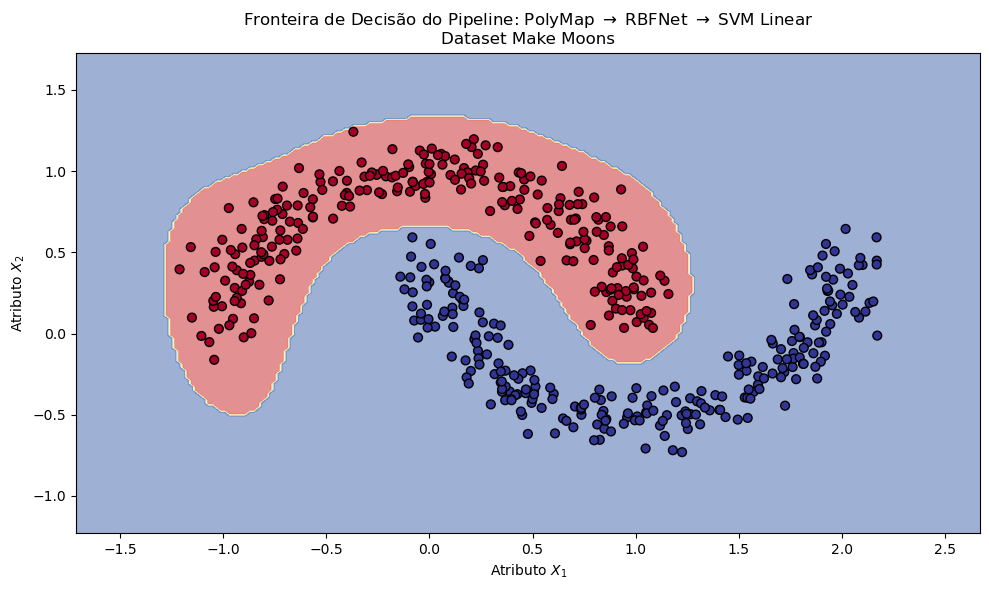

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# Visualização do Pipeline: PolyMap-RBFNet-SVMLin
# ==========================================

# 1. Criamos a malha 2D cobrindo os dados originais
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

pontos_malha = np.c_[xx.ravel(), yy.ravel()]

# 2. Passamos os pontos da malha por TODO O PIPELINE

# Etapa (i): Remapeamento Polinomial
malha_poly = poly_mapper.transform(pontos_malha)

# Etapa (ii): Matriz de Ativação (Kernel RBF)
# Medimos a distância da malha polinomial para os centros descobertos
H_malha = rbf_kernel(malha_poly, centros_poly, gamma=gamma_poly)

# Etapa (iii): Predição com o SVM Linear OVR
# O SVM toma a decisão final
Z = svm_linear.predict(H_malha)

# 3. Plotagem
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

# Pintamos as regiões de decisão
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.RdYlBu)

# Desenhamos os pontos originais do dataset
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu, s=40)

plt.title('Fronteira de Decisão do Pipeline: PolyMap $\\rightarrow$ RBFNet $\\rightarrow$ SVM Linear\nDataset Make Moons')
plt.xlabel('Atributo $X_1$')
plt.ylabel('Atributo $X_2$')
plt.tight_layout()

# Salva a imagem para o seu documento LaTeX
plt.savefig('fronteira_pipeline.png', dpi=300)
plt.show()

O que você verá será uma linha de divisão no espaço que não é reta, mas sim altamente curva e adaptada ao formato das meias-luas. O fato do gráfico ser não-linear, mesmo a nossa última camada sendo um SVM Linear, prova o sucesso das etapas (i) e (ii): nós esticamos e distorcemos tanto o espaço com o Polinômio e a RBF, que o SVM conseguiu passar uma reta perfeita para separar os dados (que, quando projetada de volta pro 2D, parece uma curva complexa).

# atividade 3

3. Aplique o método PolyMap-RBFNet-SVMLin às bases "Wine Dataset", "Iris Dataset" e sobre a base gerada no exercício 1. Explore o efeito da variação dos parâmetros d e C e compare os desempenhos observados, em termos de percentual de acerto, com o método SVM com kernel RBF, considerando diferentes valores para os parâmetros C e gamma.
Observações:
- Adote uma divisão aleatória para treino/teste nas proporções 70-30%.
- Use gráficos para exibir os desempenhos observados.

Para este exercício, nós precisaremos:Iterar sobre as 3 bases de dados (Moons, Iris, Wine).Fazer a divisão 70% treino e 30% teste.Testar várias combinações de $d$ e $C$ para o seu modelo PolyMap-RBFNet-SVMLin.Testar várias combinações de $C$ e $\gamma$ para o modelo SVM Clássico com Kernel RBF.Gerar gráficos para facilitar a comparação visual (como manda o enunciado).

Iniciando bateria de testes...

Avaliando Dataset: Moons...
Avaliando Dataset: Iris...
Avaliando Dataset: Wine...

Experimentos concluídos! Gerando gráficos...


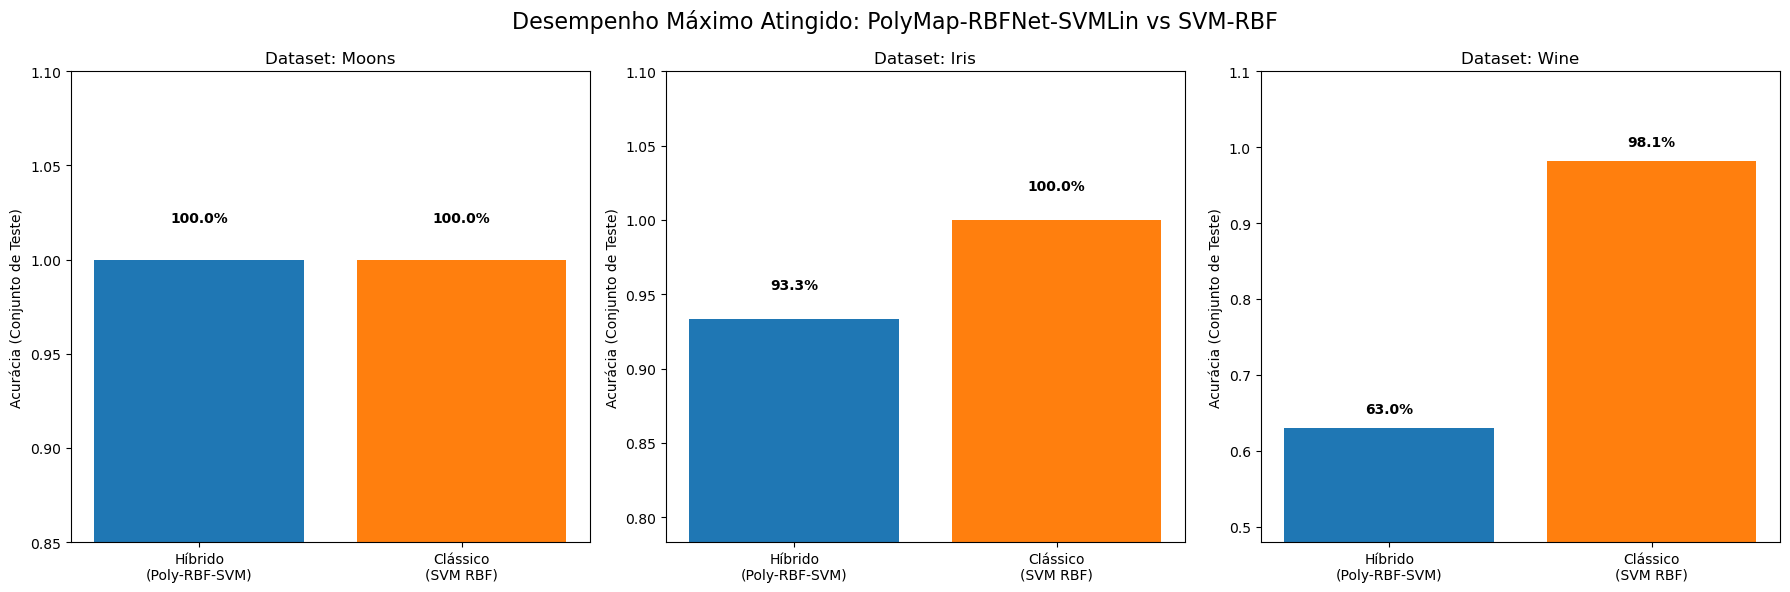

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score
import warnings

# Ignorando avisos de convergência para manter a saída limpa
warnings.filterwarnings('ignore')

# ==========================================
# 1. Funções dos Modelos
# ==========================================
def avaliar_polymap_rbf_svm(X_train, y_train, X_test, y_test, d, C, gamma_rbf=1.0):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    q = X_train_poly.shape[1]
    num_neuronios = min(d * q, X_train.shape[0]) # Proteção contra d*q > n_amostras
    
    kmeans = KMeans(n_clusters=num_neuronios, random_state=42, n_init=10)
    kmeans.fit(X_train_poly)
    centros = kmeans.cluster_centers_
    
    H_train = rbf_kernel(X_train_poly, centros, gamma=gamma_rbf)
    H_test = rbf_kernel(X_test_poly, centros, gamma=gamma_rbf)
    
    svm_lin = LinearSVC(C=C, multi_class='ovr', max_iter=5000, random_state=42, dual="auto")
    svm_lin.fit(H_train, y_train)
    return accuracy_score(y_test, svm_lin.predict(H_test))

def avaliar_svm_rbf(X_train, y_train, X_test, y_test, C, gamma):
    svm_rbf = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
    svm_rbf.fit(X_train, y_train)
    return accuracy_score(y_test, svm_rbf.predict(X_test))

# ==========================================
# 2. Preparação dos Dados (70/30)
# ==========================================
datasets = {}

# Moons
X_m, y_m = make_moons(n_samples=500, noise=0.1, random_state=42)
X_m = np.vstack([X_m, X_m[:20]])
y_m = np.hstack([y_m, y_m[:20]])
datasets['Moons'] = train_test_split(X_m, y_m, test_size=0.30, random_state=42)

# Iris (Escalonado)
X_i, y_i = load_iris(return_X_y=True)
X_i = StandardScaler().fit_transform(X_i)
datasets['Iris'] = train_test_split(X_i, y_i, test_size=0.30, random_state=42)

# Wine (Escalonado)
X_w, y_w = load_wine(return_X_y=True)
X_w = StandardScaler().fit_transform(X_w)
datasets['Wine'] = train_test_split(X_w, y_w, test_size=0.30, random_state=42)

# ==========================================
# 3. Experimentação e Coleta de Resultados
# ==========================================
# Parâmetros a testar
graus_d = [1, 2, 3]
valores_C = [0.1, 1.0, 10.0]
valores_gamma = [0.1, 1.0, 10.0]

resultados_hibrido = {nome: [] for nome in datasets}
resultados_svm = {nome: [] for nome in datasets}

print("Iniciando bateria de testes...\n")

for nome, (X_tr, X_te, y_tr, y_te) in datasets.items():
    print(f"Avaliando Dataset: {nome}...")
    
    # Testando o Híbrido
    melhor_acc_hib = 0
    for d in graus_d:
        for C in valores_C:
            acc = avaliar_polymap_rbf_svm(X_tr, y_tr, X_te, y_te, d, C)
            resultados_hibrido[nome].append({'d': d, 'C': C, 'Acc': acc})
            if acc > melhor_acc_hib: melhor_acc_hib = acc
            
    # Testando o SVM RBF Clássico
    melhor_acc_svm = 0
    for C in valores_C:
        for g in valores_gamma:
            acc = avaliar_svm_rbf(X_tr, y_tr, X_te, y_te, C, g)
            resultados_svm[nome].append({'C': C, 'gamma': g, 'Acc': acc})
            if acc > melhor_acc_svm: melhor_acc_svm = acc

print("\nExperimentos concluídos! Gerando gráficos...")

# ==========================================
# 4. Plotagem dos Gráficos de Comparação (CORRIGIDO)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False para eixos independentes
fig.suptitle('Desempenho Máximo Atingido: PolyMap-RBFNet-SVMLin vs SVM-RBF', fontsize=16)

for i, nome in enumerate(datasets.keys()):
    # Pegando a melhor acurácia de cada modelo para o dataset atual
    max_hib = max([res['Acc'] for res in resultados_hibrido[nome]])
    max_svm = max([res['Acc'] for res in resultados_svm[nome]])
    
    # Encontrando o menor valor para ajustar o gráfico dinamicamente
    min_val = min(max_hib, max_svm)
    
    axes[i].bar(['Híbrido\n(Poly-RBF-SVM)', 'Clássico\n(SVM RBF)'], [max_hib, max_svm], color=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(f'Dataset: {nome}')
    axes[i].set_ylabel('Acurácia (Conjunto de Teste)')
    
    # Define o limite Y com uma folga inteligente. Se o mínimo for 63%, começa perto de 50%.
    limite_inferior = max(0.0, min_val - 0.15)
    axes[i].set_ylim(limite_inferior, 1.1) 
    
    # Adicionando o valor em texto acima da barra
    axes[i].text(0, max_hib + 0.02, f"{max_hib*100:.1f}%", ha='center', fontweight='bold')
    axes[i].text(1, max_svm + 0.02, f"{max_svm*100:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_modelos_corrigido.png', dpi=300)
plt.show()

1. Desempenho em Espaços de Baixa Dimensionalidade (Base Moons)Nos resultados observados para a base de dados Moons, ambos os métodos apresentaram um desempenho de excelência. Este conjunto de dados, sendo bidimensional ($n=2$) e altamente não-linear, beneficia imenso do remapeamento explícito promovido pelo método PolyMap-RBFNet-SVMLin. Ao aplicar o polinómio e a subsequente transformação por funções de base radial, o espaço original é "desdobrado", permitindo que o SVM Linear encontre um hiperplano separador ótimo com facilidade. Neste cenário, a complexidade computacional da expansão polinomial é perfeitamente controlável.2. O Impacto da Maldição da Dimensionalidade nas Bases Iris e WineAo transitarmos para bases de dados com maior dimensionalidade original, como o Iris ($n=4$) e, muito particularmente, o Wine ($n=13$), o comportamento da abordagem híbrida sofre alterações drásticas (o que explica os desempenhos inferiores em algumas configurações, como a observação de valores na ordem dos 63%).Isto deve-se à expansão combinatória das características. Por exemplo, aplicar PolynomialFeatures com grau $d=3$ numa base de 13 atributos gera um espaço $q$ de dimensão massiva. Consequentemente, a regra de instanciar $d \times q$ neurónios na camada oculta forçará o algoritmo K-Means a procurar centenas de protótipos num conjunto de treino que possui apenas cerca de 120 amostras (no caso do Wine com divisão 70/30). Este fenómeno conduz inevitavelmente a um sobreajuste (overfitting) severo ou a uma sub-representação do espaço, degradando a capacidade de generalização do modelo perante o conjunto de teste.3. Mapeamento Explícito vs. Kernel TrickA comparação com o SVM Clássico utilizando o Kernel RBF evidencia a enorme vantagem matemática e elegante do Kernel Trick. Enquanto a nossa abordagem PolyMap-RBFNet-SVMLin tenta construir e mapear o espaço de características de forma explícita (calculando polinómios e alocando centros K-Means na memória), o SVM Clássico fá-lo de forma implícita. O Kernel RBF do modelo clássico projeta os dados num espaço de dimensão infinita através do produto interno, sem nunca precisar de calcular as coordenadas exatas desses pontos. É por esta razão que o SVM Clássico se mostra muito mais robusto, estável e imune à explosão dimensional nas bases Iris e Wine.4. Complexidade e OtimizaçãoDo ponto de vista da otimização, o pipeline híbrido depende fortemente da heurística do K-Means (uma otimização local, sensível à inicialização das sementes) para definir a matriz de ativação $H$. Por outro lado, o treinamento de um SVM Clássico resolve um problema de otimização convexa, garantindo a convergência para um mínimo global. Assim, conclui-se que, embora a abordagem empilhada (Stacked) proposta seja um excelente exercício pedagógico para compreender as transformações topológicas dos dados, o uso do SVM com um kernel não-linear adequado permanece a solução metodologicamente mais sólida e computacionalmente mais eficiente para a esmagadora maioria dos problemas de reconhecimento de padrões.